# In-situ Electrochemical SAXS analysis

In [35]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import glob
import os
import numpy as np
import pandas as pd
# import scienceplots
from galvani import BioLogic as BL
import eclabfiles as ecf
from datetime import datetime, timedelta
import ipywidgets as widgets
from IPython.display import display
from pybaselines import Baseline, utils
from scipy.signal import savgol_filter # Savitzky-Golay filter

# Define Functions

# Function for reading files 

In [3]:
def read_data(file_name):
    legend_temp = []
    data_line_temp = []
    time_stamp_temp = []
    data_storing = False
    
    with open(file_name, 'r') as file:
        for line in file:
            if 'q(A-1)' in line:
                data_storing = True
                continue
            if 'Comment' in line:
                legend_temp = line.split()[4]
            if 'Date' in line:
                time_stamp_temp = line.split()[2] 
            if data_storing:
                data_line_temp.append(line.strip())
    df_temp= pd.DataFrame([line.split() for line in data_line_temp])
    df_temp= df_temp.astype(float)

    return legend_temp, time_stamp_temp ,df_temp

    

# Find files corresponding to Electrochemical events

In [4]:
def find_nearest_time(target_time, time_dict):
    new_time_dict = {}
    
    base_time = datetime.strptime(time_dict[1], '%Y-%m-%dT%H:%M:%S')

    for key in time_dict:
        current_time = datetime.strptime(time_dict[key], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = key
    
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    
    
    return nearest_key, new_time_dict


# Read the variables file

In [5]:
# Initialize variables
directory_path = None
mpr_file_path = None
saxs_min_limit = None
saxs_max_limit = None
waxs_min_limit = None
waxs_max_limit = None

with open(r'E:\SAXS_WAXS\variables.txt', 'r') as file:
    lines = file.readlines()

for line in lines:
    stripped_line = line.strip()  # Remove leading/trailing whitespace and newlines
    
    # Skip comments and empty lines
    if not stripped_line or stripped_line.startswith("#"):
        continue
    
    if directory_path is None:
        directory_path = stripped_line
    elif mpr_file_path is None:
        mpr_file_path = stripped_line
    elif saxs_min_limit is None:
        saxs_min_limit = float(stripped_line)
    elif saxs_max_limit is None:
        saxs_max_limit = float(stripped_line)
    elif waxs_min_limit is None:
        waxs_min_limit = float(stripped_line)
    elif waxs_max_limit is None:
        waxs_max_limit = float(stripped_line)


# Example: Use the min and max limits
print(f"Files Directory path: {directory_path}")
print(f"SAXS Contourplot Limits: Min = {saxs_min_limit}, Max = {saxs_max_limit}")
print(f"WAXS Contourplot Limits: Min = {waxs_min_limit}, Max = {waxs_max_limit}")


Files Directory path: C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20241120_SKJB_DOLDMEtto3_Al-windows\test
SAXS Contourplot Limits: Min = 0.13, Max = 3.0
WAXS Contourplot Limits: Min = 22.0, Max = 30.0


# Function for the contour plots

In [6]:
import tkinter as tk
from tkinter import filedialog
import os

def contourplot(plot_type, data_normalization, data_dictionary, new_time_dict, min_limit, max_limit, cmap_min=None, cmap_max=None, Normalization_file=None, save_plot=False, filename="contour_plot.png"):
    import matplotlib.ticker as mticker
    from matplotlib.ticker import EngFormatter
    from scipy.ndimage import gaussian_filter

    wavelength_nm = 0.154 # wavelength for Cu K_alpha in nm

    # Plot setup
    fntsize = 16
    plt.style.use('default')
    keys = list(new_time_dict.keys())
    time_t1 = []
    Intensity_list = []
    print(starting_file, discharge_file, last_file)
    X1_data_temp = 10 * data_dictionary[starting_file].iloc[:, 0]

        # Convert q to two-theta if plot_type is 'waxs'
    if plot_type == 'waxs':
        X1_data_temp = 2 * np.degrees(np.arcsin((wavelength_nm * X1_data_temp) / (4 * np.pi)))
        x_label = '2θ (°)'
    else:
        x_label = 'q (nm $^{-1}$)'


    # Filter data in range
    indices_within_range = np.where((X1_data_temp >= min_limit) & (X1_data_temp <= max_limit))
    X1_data_filtered_positions = X1_data_temp.iloc[indices_within_range]
    start_row = np.min(indices_within_range)
    end_row = np.max(indices_within_range)

    # Process data
    for file_number in range(starting_file, last_file + 1):
        if data_normalization == 'relative':
            Y1_data = [(data_dictionary[file_number].iloc[start_row:end_row + 1, 1]) / data_dictionary[Normalization_file].iloc[start_row:end_row + 1, 1]]
        else:
            Y1_data = [(data_dictionary[file_number].iloc[start_row:end_row + 1, 1])]
        time_t1.append(float(keys[file_number - 1] - keys[starting_file - 1]))
        Intensity_list.append(list(Y1_data))
        capacity = [(t * applied_current) / (active_material_mass * 3.6) for t in time_t1]

    # Convert data to array
    normIntensity_array = np.array(Intensity_list)
    X, Y = np.meshgrid(X1_data_filtered_positions, capacity)
    normIntensity_flat = normIntensity_array[:, 0, :]
    smoothed_intensity = gaussian_filter(normIntensity_flat, sigma=2)
    cmap1 = plt.colormaps.get_cmap('viridis')

    # Set up plot
    cycle_capacity = ((elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0]) * applied_current) / (active_material_mass * 3.6)
    min_capacity = cycle_capacity.min()
    max_capacity = cycle_capacity.max()
    fig, axs = plt.subplots(1, 2, figsize=(8, 5), sharey=True, gridspec_kw={'width_ratios': [1, 4]})
    axs[0].plot(elec_df_2['Ewe/V'], cycle_capacity, color='r')
    axs[0].invert_xaxis()
    axs[0].set_ylabel('Specific capacity (mAh g $^{-1}$)', fontsize=fntsize)
    axs[0].set_xlabel('Potential (V)', fontsize=fntsize)
    axs[0].set_ylim(min_capacity, max_capacity)
    if plot_type == 'saxs':
        contour = axs[1].contourf(X, Y, (smoothed_intensity), cmap=cmap1, vmin=cmap_min, vmax=cmap_max)
    else:
         contour = axs[1].contourf(X, Y, smoothed_intensity, cmap=cmap1, vmin=cmap_min, vmax=cmap_max)
   
    cbar = fig.colorbar(contour, ax=axs[1], label='Relative intensity' if data_normalization == 'relative' else 'Intensity (a.u.)')
    cbar.ax.yaxis.label.set_size(fntsize)
    cbar.ax.tick_params(labelsize=12)

    # Set colorbar ticks to show only min, mid, and max
    cbar_min = cmap_min if cmap_min is not None else smoothed_intensity.min()
    cbar_max = cmap_max if cmap_max is not None else smoothed_intensity.max()
    cbar_mid = (cbar_min + cbar_max) / 2
    cbar.set_ticks([cbar_min, cbar_mid, cbar_max])
    cbar.set_ticklabels([f'{cbar_min:.3f}', f'{cbar_mid:.3f}', f'{cbar_max:.3f}'])

    fig.subplots_adjust(wspace=0)
    axs[1].set_xlabel(x_label, fontsize=fntsize)

    if plot_type == 'saxs':
        axs[1].set_xscale('log')
        axs[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
        axs[1].xaxis.set_minor_formatter(mticker.ScalarFormatter())
        ticks = np.arange(min_limit, max_limit, 1)
        tick_labels = [f'{tick:.1f}' for tick in ticks]
        axs[1].set_xticks(ticks)
        axs[1].set_xticklabels(tick_labels, fontsize=fntsize)
        axs[1].xaxis.set_minor_locator(mticker.NullLocator())

    axs[0].tick_params(axis='both', labelsize=12)
    axs[1].tick_params(axis='both', labelsize=12)

    # Optional saving
    if save_plot:
        root = tk.Tk()
        root.withdraw()
        save_path = filedialog.asksaveasfilename(defaultextension=".png", initialfile=filename, filetypes=[("PNG files", "*.png")])
        if save_path:
            plt.savefig(save_path, dpi=600)
            print(f"Plot saved to {save_path}")

    plt.show()


# Smooth the data

In [7]:
def smooth_data(data, window_length, polyorder):
    return savgol_filter(data, window_length, polyorder)

# Upload/read data files for SAXS

In [11]:
directory_path = r'\\shares.is.sbg.ac.at\GFS_EML\SAXS_Backup\inhouse\PronoyD\Electrolyte_variation\After_Beamtime\2503SKJB\20250102_SKJB_1M-LiTFSI-DiGlyme_0pt4_LiNO3\cycle'
mpr_file_path = '20250102_SKJB_1pt5mg_1M-LiTFSI_DiGlyme_0pt4-LiNO3_1G1PS_C02.mpr'
os.chdir(directory_path)
mpr = BL.MPRfile(mpr_file_path)

file_list = glob.glob('*_0_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)
    
print('Number of files:',key)

Number of files: 921


# Plot Data

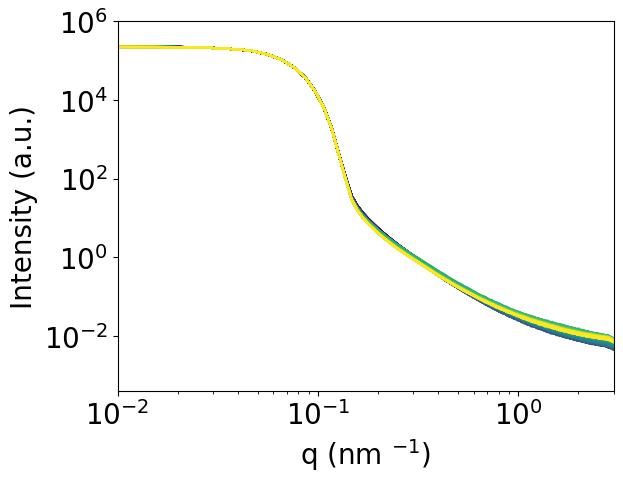

In [12]:

file_min = 5  # Start index of the files to plot
file_max = 350  # End index of the files to plot

plt.figure()
plt.style.use('default')

# Get 'viridis' colormap
cmap = plt.get_cmap('viridis')
files_to_plot = list(file_dictionary.keys())[file_min:file_max+1]  # Select keys in the specified range
num_files = len(files_to_plot)
colors = cmap(np.linspace(0, 1, num_files))  # Generate a range of colors for each selected file

# Plot each file in the specified range
for idx, (ikey, color) in enumerate(zip(files_to_plot, colors)):
    X_data = 10 * file_dictionary[ikey].iloc[:, 0]  # Convert from inverse Å to inverse nm
    Y_data = file_dictionary[ikey].iloc[:, 1]
    plt.plot(X_data, Y_data, color=color, label=f"File {ikey}")

# Setting graph attributes
plt.xlim(0.01,3)
plt.ylim(0.0004,1000000)
plt.xlabel('q (nm $^{-1}$)', fontsize = 20)
plt.ylabel('Intensity (a.u.)', fontsize = 20)
plt.tick_params(labelsize = 20)

plt.xscale('log')
plt.yscale('log')

#plt.legend(title="Files", loc="best", fontsize="small", bbox_to_anchor=(1, 1))
#plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label='File Index', orientation='vertical')  # Optional: colorbar for reference
plt.show()


# Load electrochemical (EC Lab) file

Indices for cycle change [961, 9948, 18276, 25508, 32547, 38078]

Absolute times for change in electrochemical state: 
[960.00037574835, 45880.46937381284, 87508.92681289604, 123656.68346245773, 158840.72625318915, 186492.12597957533]
Applied current 0.12554999
Mass of active material 1.4991043218925817 mg


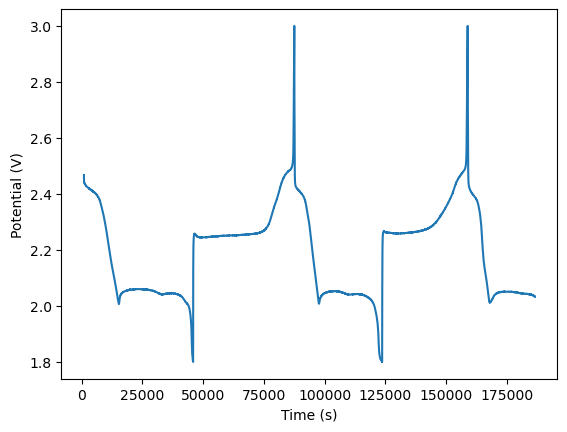

In [13]:
plt.figure()

elec_df_temp = pd.DataFrame(mpr.data)
rate = float(input("Enter discharge-charge rate, value of N in (C/N):"))

    # Filter the data for the OCV from the dataframe 
filter = elec_df_temp['Ns'] != 0
elec_df = elec_df_temp[filter]
elec_df.to_csv('electrochem_datafile.txt', sep = '\t')

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
absolute_times_for_electrochemical_state_change = []

# Add the very first values of the index and time 
cycle_change_index.append(elec_df.index[0])
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[0], 'time/s'])

for line in range(len(elec_df['Ns'])-1):
    if elec_df['Ns'].iloc[line] != elec_df['Ns'].iloc[line+1]:
        cycle_change_index.append(elec_df.index[line+1])
        absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

cycle_change_index.append(elec_df.index[line+1]) #Takes the index for the last file also  
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

print("Indices for cycle change", cycle_change_index)
print("\nAbsolute times for change in electrochemical state: ")
print(absolute_times_for_electrochemical_state_change)

# Plot the read electrochemical file
Elec_Xdata = elec_df['time/s']
Elec_Ydata = elec_df['Ewe/V']
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')
applied_current = abs(elec_df['control/V/mA'].iloc[0])
print("Applied current",applied_current)
active_material_mass = (abs(elec_df['control/V/mA'].iloc[0])*1000*rate)/1675.0
print(f"Mass of active material {active_material_mass} mg")

# Data segregation 

Total number of cycles: 3

Biologic data file line details:
Line numbers for each electrochemical change event : [18276, 25508, 32547]
Corresponding times for each electrochemical change event:  ['87508.93', '123656.68', '158840.73']
Files numbers for SAXS data [433, 612, 785]


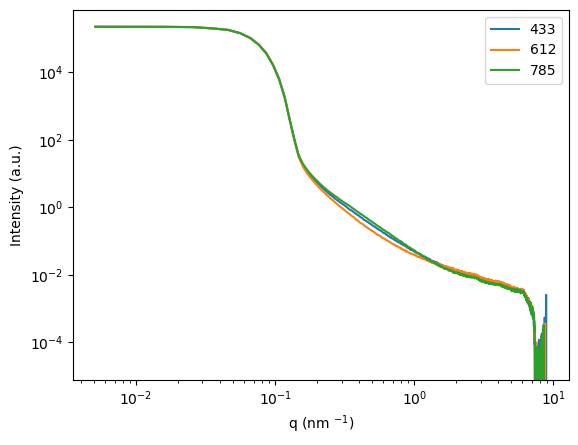

In [30]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Filter the DataFrame by the condition
starting_cycle = int(input("Starting cycle to plot:"))
end_cycle = int(input("Final cycle to plot:"))


change_cycle_line = []
discharge_start_time = []
saxs_file_numbers = []

starting_index_for_EC_data = 2*starting_cycle-2
ending_index_for_EC_data = 2*end_cycle

print('\nBiologic data file line details:')
print('Line numbers for each electrochemical change event :',
       [cycle_change_index[_] for _ in range(starting_index_for_EC_data, ending_index_for_EC_data+1)])
print('Corresponding times for each electrochemical change event: ', 
      [f"{absolute_times_for_electrochemical_state_change[i]:.2f}" for i in range(2*starting_cycle-2, 2*end_cycle+1)])

# creates a new data frame for the plot
elec_df_2 = elec_df.iloc[cycle_change_index[starting_index_for_EC_data] - cycle_change_index[0] : 
                         cycle_change_index[ending_index_for_EC_data] - cycle_change_index[0]]
elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')

plt.style.use('default')
plt.figure()

# find the corresponding starting abd ending SAXS file
for entry in range(starting_index_for_EC_data, ending_index_for_EC_data+1):
    saxs_file_index, new_time_dict  = find_nearest_time(absolute_times_for_electrochemical_state_change[entry], time_stamp)
    saxs_file_numbers.append(saxs_file_index)
    X1_data = 10*file_dictionary[saxs_file_index].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y1_data = file_dictionary[saxs_file_index].iloc[:,1]
    plt.plot(X1_data, Y1_data, label= saxs_file_index)
""" # Printing the file details for manual verification of file numbers   
    print(f"Starting SAXS file no.: {saxs_file_index}")
    print('Time stamps:')
    print(time_stamp[saxs_file_index])"""

starting_file = saxs_file_numbers[0]
discharge_file = saxs_file_numbers[1]
last_file = saxs_file_numbers[-1]
print("Files numbers for SAXS data",saxs_file_numbers)
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.xscale('log')
plt.yscale('log')

# Not required

In [ ]:
plt.figure()
print(f'profile for cycle number: {starting_cycle},{end_cycle}')
plt.style.use('default')
x_lim_min =0.15
x_lim_max = 3.15

plot1 = plt.subplot2grid((4, 4), (0, 0), colspan=4) 
plot2 = plt.subplot2grid((4, 4), (1, 0), rowspan=3, colspan=2) 
plot3 = plt.subplot2grid((4, 4), (1, 2), rowspan=3, colspan=2)

relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
plot1.plot(relative_time, elec_df_2['Ewe/V'], color = 'r')
# plot1.set_xlabel('Time(s)')
plot1.set_ylabel('Potential (V)')
plot1.set_xticks([])


norm = Normalize(vmin = starting_file, vmax = discharge_file+1)

for file_number in range(starting_file , discharge_file+1): 
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    mask = Y_data > 0
    X_data = X_data[mask]
    Y_data = Y_data[mask]
    
    color=cm.viridis(norm(file_number))
    plot2.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
# plot2.legend()
plot2.set_xlim(x_lim_min, x_lim_max)
plot2.set_ylim(0.002, 100)
plot2.set_xlabel('q (nm $^{-1}$)')
plot2.set_ylabel('Intensity (a.u.)')


"""plot2.set_xlim(1,30)
plot2.set_ylim(0.0004,0.01)"""
# plot2.set_title('charging')
plot2.set_yticks([])
plot2.set_yticklabels([])
plot2.set_xscale('log')
plot2.set_yscale('log')


norm = Normalize(vmin = discharge_file+1, vmax = last_file)

for file_number in range(discharge_file+1 , last_file+1):  
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    color=cm.viridis(norm(file_number))
    plot3.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
    
# plot3.legend()
plot3.set_xlim(x_lim_min, x_lim_max)
plot3.set_ylim(0.002, 100)
plot3.set_xlabel('q (nm $^{-1}$)')
"""plot3.set_xlim(1,30)
plot3.set_ylim(0.0004,0.01)"""
plot3.set_yticks([])
plot3.set_yticklabels([])
# plot3.set_title('discharge')
plot3.set_xscale('log')
plot3.set_yscale('log')
plt.tight_layout()

# SAXS Colourplot without background correction 

profile for cycle number: 1 to 1
6 228 433


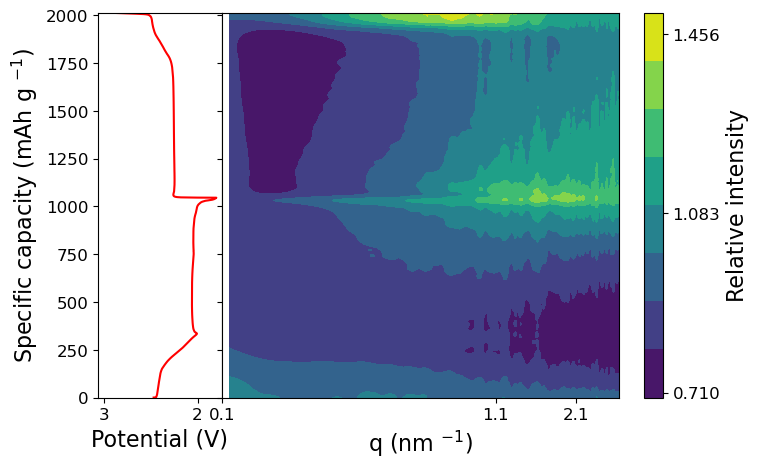

6 228 433


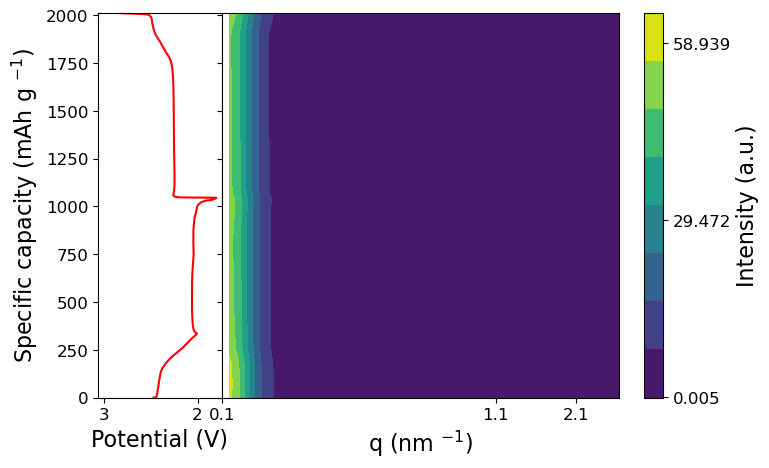

In [15]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('saxs', 'relative', file_dictionary, new_time_dict, saxs_min_limit, 3, Normalization_file= starting_file, save_plot = False, filename ="satDME.png")
contourplot('saxs', 'absolute', file_dictionary, new_time_dict, saxs_min_limit, saxs_max_limit)

# Background correction with empty cell subtraction 

File used for background: background_saxs.dat


(0.01, 6)

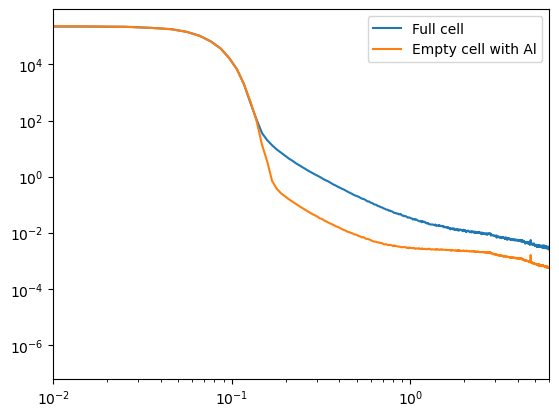

In [16]:
# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\After_Beamtime\2503SKJB\20240604_2503-SKJB_6MECDEC_100volHFE')
saxs_background_file =  glob.glob('background_saxs.dat')#glob.glob('20240730_Empty_Cell_saxs.dat')
#print(file_list)

for file in saxs_background_file:
    a1,a2,SAXS_background = read_data(file)

plt.figure()  
print('File used for background:',file)

plt.plot(10*file_dictionary[1].iloc[:,0],file_dictionary[1].iloc[:,1], label = 'Full cell')
plt.plot(10*SAXS_background.iloc[:,0], SAXS_background.iloc[:,1], label = 'Empty cell with Al')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(0.01,6)
#plt.ylim(0.001,40)
#print(SAXS_background)
# print(file_dictionary[1].head())
# print(file_dictionary[250].head())

# Create a new dictionary with corrected SAXS

(0.0001, 40)

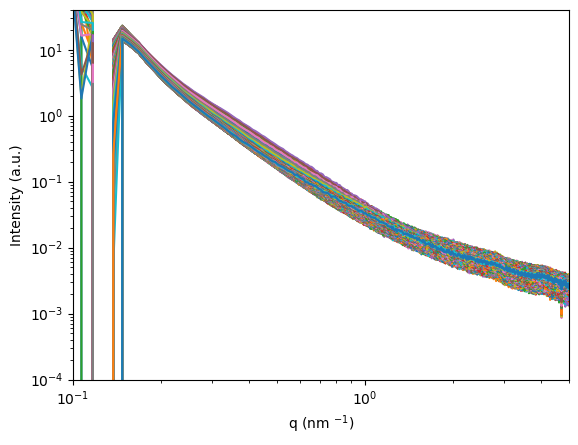

In [17]:
plt.figure()
emptyCell_corrected_saxs_files = {}
for ikey in file_dictionary:
    X_data = file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - SAXS_background.iloc[:len(Y_data),1]
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_saxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1,5)
plt.ylim(0.0001,40)
#print(corrected_waxs_files[1].head(30))

profile for cycle number: 1 to 1
6 228 433


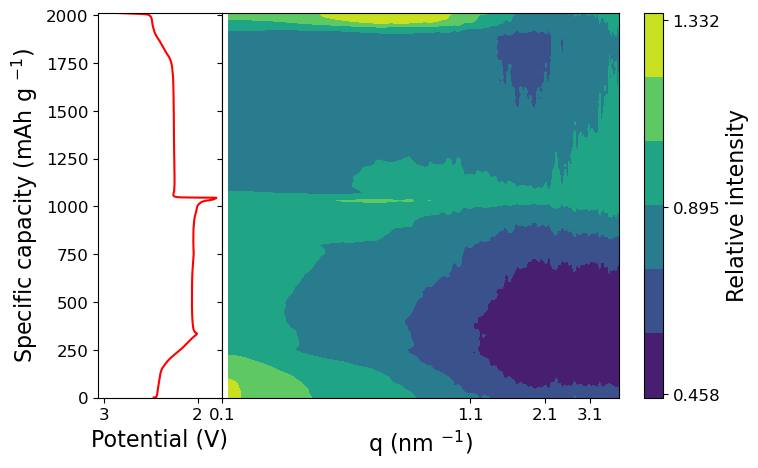

6 228 433


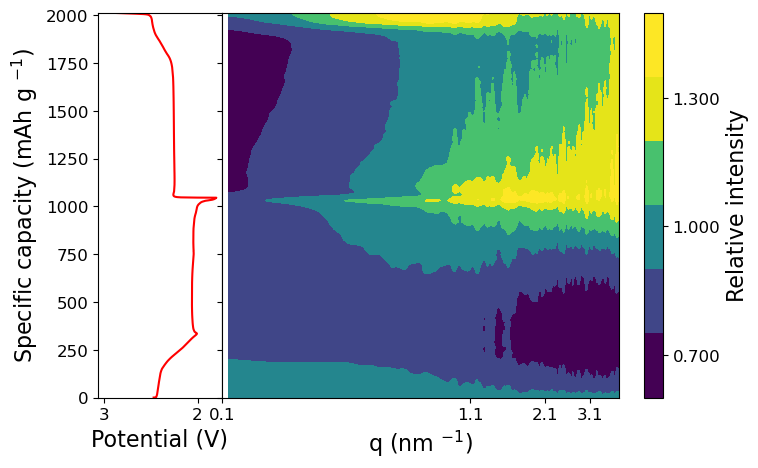

In [18]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('saxs', 'relative', emptyCell_corrected_saxs_files, new_time_dict, 0.14, 4,  Normalization_file= discharge_file, save_plot= False)
contourplot('saxs', 'relative', emptyCell_corrected_saxs_files, new_time_dict, 0.14, 4,  cmap_min= 0.7, cmap_max=1.3,Normalization_file= starting_file, save_plot= False)

# Manual correction with perticular curve

# WAXS data polotting

In [19]:
file_list_waxs = glob.glob('*_1_*.dat')
#print(file_list)


legend_waxs = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp_waxs = {} #Dictionary to store the time of file creation
key = 0
file_dictionary_waxs = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list_waxs:
    key += 1
    legend_waxs[key], time_stamp_waxs[key], file_dictionary_waxs[key] = read_data(data_file)
    
print('Number of files:',key)


Number of files: 921


# Plot the WAXS data

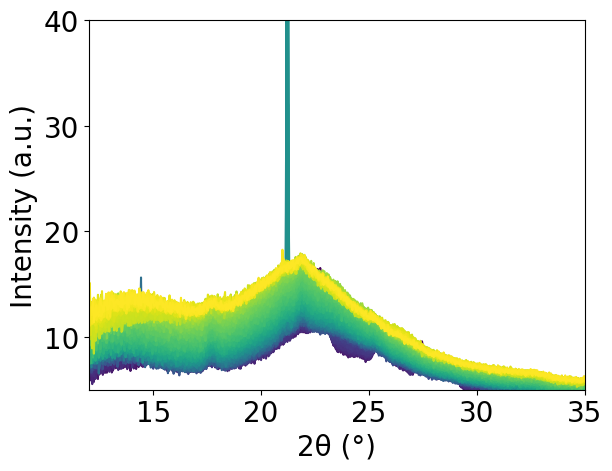

In [20]:
file_min = 5  # Start index of the files to plot
file_max = 246  # End index of the files to plot

plt.figure()
plt.style.use('default')

# Get 'viridis' colormap
cmap = plt.get_cmap('viridis')
files_to_plot = list(file_dictionary_waxs.keys())[file_min:file_max+1]  # Select keys in the specified range
num_files = len(files_to_plot)
colors = cmap(np.linspace(0, 1, num_files))  # Generate a range of colors for each selected file

# Plot each file in the specified range
for idx, (ikey, color) in enumerate(zip(files_to_plot, colors)):
    X_data = 10 * file_dictionary_waxs[ikey].iloc[:, 0]  # Convert from inverse Å to inverse nm
    Y_data = file_dictionary_waxs[ikey].iloc[:, 1]
    plt.plot(2 * np.degrees(np.arcsin((0.154 * X_data) / (4 * np.pi))), 
             Y_data*1000, color=color, label=f"File {ikey}") # 0.154, wavelenght of Cu K alpha

# Setting graph attributes
plt.xlim(12,35)
plt.ylim(5,40)
plt.xlabel('2θ (°)', fontsize = 20)
plt.ylabel('Intensity (a.u.)', fontsize = 20)
#plt.yticks([])
plt.tick_params(labelsize = 20)


profile for cycle number: 1 to 1
6 228 433


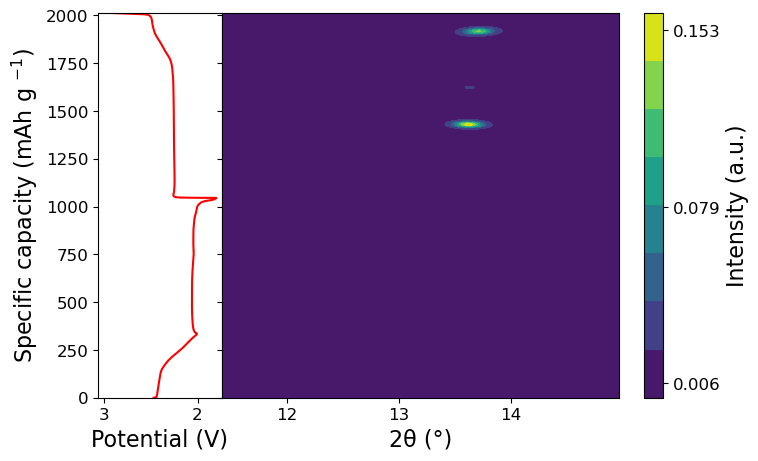

In [21]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('waxs', 'absolute', file_dictionary_waxs, new_time_dict, 10, 15, cmap_min= None, cmap_max= None)

# Background correction and plotting for the WAXS

# Background correction with empty cell subtraction 

File used for WAXS background: background_waxs.dat


Text(0, 0.5, 'Intensity (a.u.)')

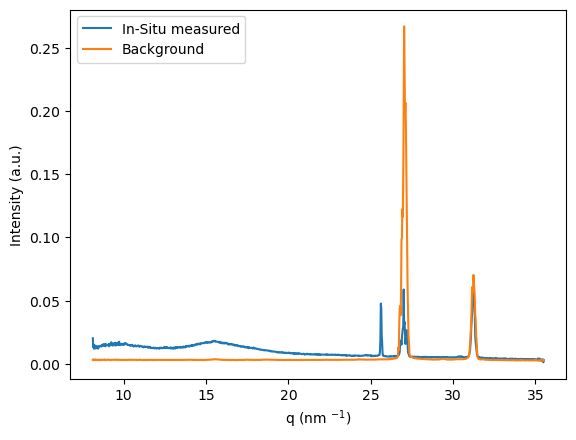

In [22]:
waxs_background_file =  glob.glob('background_waxs.dat')
#glob.glob('20240730_Empty_Cell_waxs.dat')
WAXS_background = {} # Dictionary for storing all the pandas data file 

for file in waxs_background_file:
    a1,a2,WAXS_background = read_data(file)
    
print('File used for WAXS background:', file)
plt.figure()
plt.plot(10*file_dictionary_waxs[1].iloc[:,0], file_dictionary_waxs[400].iloc[:,1], label = "In-Situ measured")
plt.plot(10*WAXS_background.iloc[:,0], 2.4*WAXS_background.iloc[:,1], label = 'Background')
plt.legend()
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

(-0.02, 0.05)

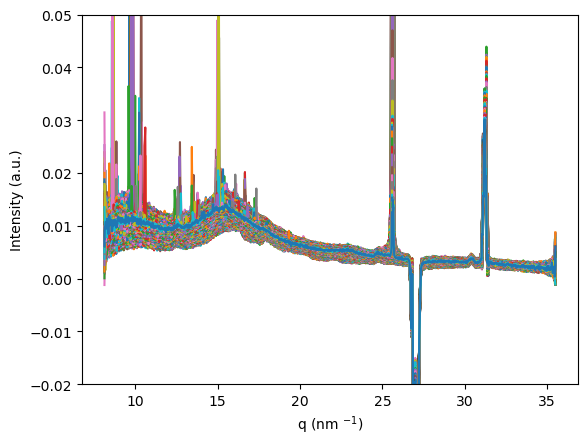

In [23]:
plt.figure()
emptyCell_corrected_waxs_files = {}
for ikey in file_dictionary_waxs:
    X_data = file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    modified_Y = Y_data - WAXS_background.iloc[:,1]
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.ylim(-0.02,0.05)
#print(corrected_waxs_files[1].head(30))

# Empty cell subtraction by matching peak at 9.68 

In [ ]:
plt.figure()
emptyCell_corrected_waxs_files2 = {}

for ikey in file_dictionary_waxs:
    # Extract X and Y data for the current file
    X_data = file_dictionary_waxs[ikey].iloc[:, 0]
    Y_data = file_dictionary_waxs[ikey].iloc[:, 1]
    
    # Interpolate Y values at X = 9.68 for both Y_data and WAXS_background
    target_X = 3.4
    if X_data.min() <= target_X <= X_data.max():
        Y_value_at_target = np.interp(target_X, X_data, Y_data)
        background_Y_value_at_target = np.interp(target_X, WAXS_background.iloc[:, 0], WAXS_background.iloc[:, 1])

        # Calculate the difference to align the background
        offset = Y_value_at_target - background_Y_value_at_target
        aligned_WAXS_background = WAXS_background.iloc[:, 1] + offset

        # Now subtract the aligned background from the raw Y_data
        modified_Y = Y_data - aligned_WAXS_background
#        plt.plot(10 * X_data, file_dictionary_waxs[ikey].iloc[:,1], label=f"raw {ikey}")
 #       plt.plot(10 * X_data, aligned_WAXS_background, label=f"background {ikey}")
        plt.plot(10 * X_data, modified_Y, label=f"Corrected {ikey}")

        # Store the results in the dictionary
        df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
        emptyCell_corrected_waxs_files2[ikey] = df
    else:
        print(f"Target X value {target_X} is out of range for file {ikey}")

# Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.ylim(-0.02, 0.05)
plt.show()

In [ ]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('waxs', 'relative', emptyCell_corrected_waxs_files, new_time_dict, 15, 29, cmap_min= None , cmap_max= None, Normalization_file= discharge_file)
contourplot('waxs', 'absolute', emptyCell_corrected_waxs_files, new_time_dict, 22, 30, cmap_min= None , cmap_max= None, save_plot= True)
contourplot('waxs', 'absolute', emptyCell_corrected_waxs_files2, new_time_dict, 15, waxs_max_limit, cmap_min= None, cmap_max= None)

# Background correction with a polynomial (correction with only one background file)

[0.00820582 0.00817533 0.00814587 ... 0.00178232 0.00177114 0.0017602 ]
first file printed as corrected_waxs.txt


Text(0, 0.5, 'Intensity (a.u.)')

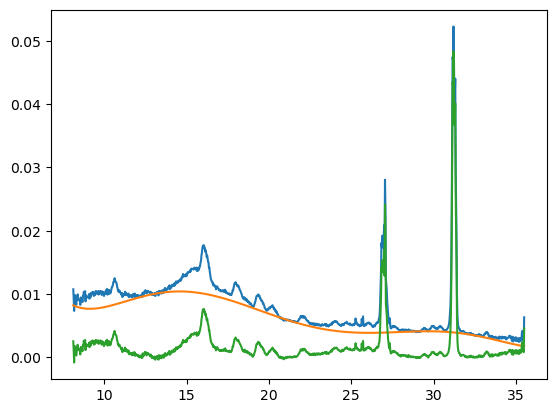

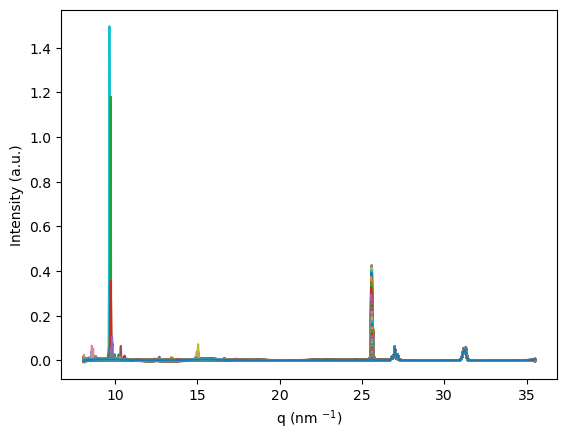

In [24]:
X_data = []
Y_data = []

for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary_waxs[files].iloc[:,1]
    else:
        x = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        y = file_dictionary_waxs[files].iloc[:,1]
        X_data += x
        Y_data += y

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 6)[0]
print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

output_filename = "corrected_waxs.txt"
with open(output_filename, 'w') as f:
    for x,y in zip(X_data, modified_Y):
        f.write(f"{x}\t{y}\n")

print(f"first file printed as {output_filename}")

# Create background corrected WAXS dataframe

plt.figure("After polynomial background correction")

corrected_waxs_files = {}
for ikey in file_dictionary_waxs:
    X_data = file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
#print(corrected_waxs_files[1].head(30))


# Correction with polynomial background on individual files 

filtered position: 220, 633, value: 1.3984111250912972, 2.499543240749458


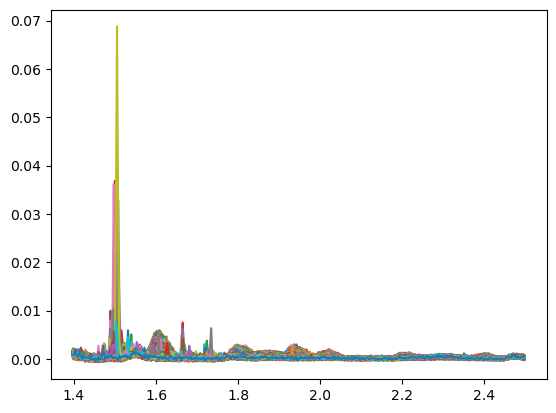

In [25]:
corrected_individual_waxs_files = {}

# filter the range for the WAXS
filtered_X_range_min = np.max(np.where(X_data <= 1.4))
filtered_X_range_max = np.max(np.where(X_data <= 2.5))
# print(empty_cell_corrected_waxs_files)
print(f"filtered position: {filtered_X_range_min}, {filtered_X_range_max}, value: {X_data[filtered_X_range_min]}, {X_data[filtered_X_range_max]}")

for ikey in file_dictionary_waxs:
    min_val = 0
    max_val = 0
    modified_Y = 0
    X2_values = file_dictionary_waxs[ikey].iloc[filtered_X_range_min:filtered_X_range_max,0] 
    Y1_values = file_dictionary_waxs[ikey].iloc[filtered_X_range_min:filtered_X_range_max,1]
    
    # define baselines for individual files and subtract from the data
    baseline_filter = Baseline(x_data = X2_values)
    baseline = baseline_filter.modpoly(Y1_values, poly_order= 5)[0]
    modified_Y = Y1_values - baseline
    plt.plot(X2_values, modified_Y)
    # Smooth the data
    #smoothed_Y = smooth_data(modified_Y, window_length=11, polyorder=2)

    # min_val = np.min(smoothed_Y)
    # max_val = np.max(smoothed_Y)
    #normalized_Y = smoothed_Y #'(smoothed_Y - min_val)/(max_val - min_val)' # Normalized the data between [0,1]
    df = pd.DataFrame({'X_data': X2_values, 'Modified_Y': modified_Y}) # change the 'Modified_Y' as per the requirement, raw, smoothened or smoothened plus normalized 
    corrected_individual_waxs_files[ikey] = df

# Colour plot of Background corrected WAXS

profile for cycle number: 2 to 2
433 612 785


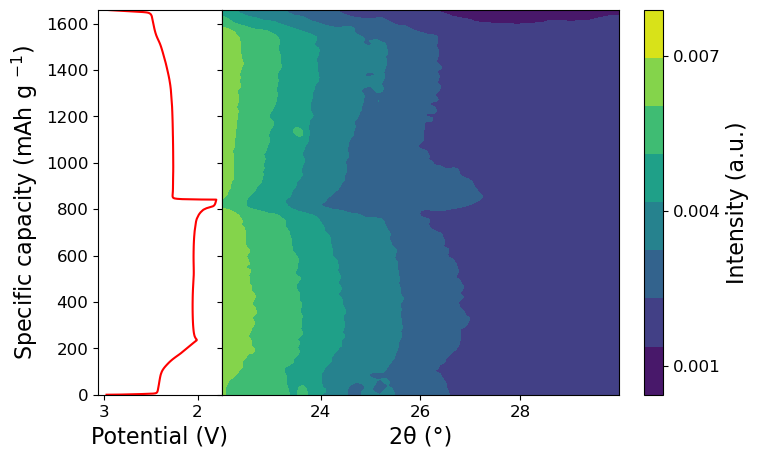

433 612 785


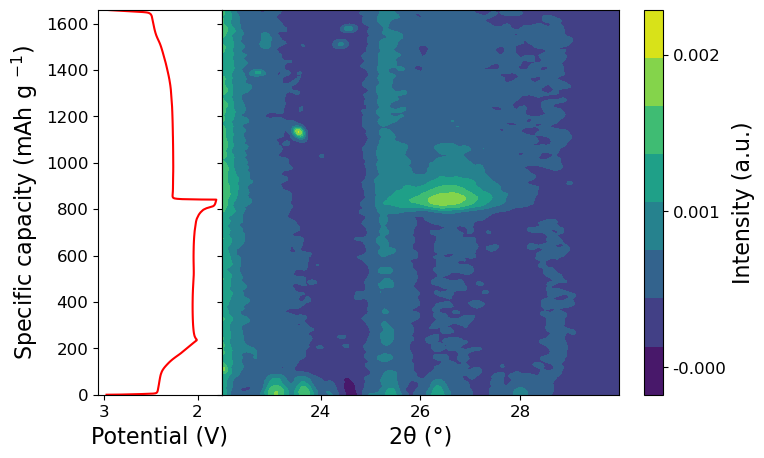

In [31]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('waxs', 'absolute', corrected_waxs_files, new_time_dict, waxs_min_limit, waxs_max_limit)
contourplot('waxs', 'absolute', corrected_individual_waxs_files, new_time_dict, 22, 30, save_plot= False)

# Waterfall plot for SAXS

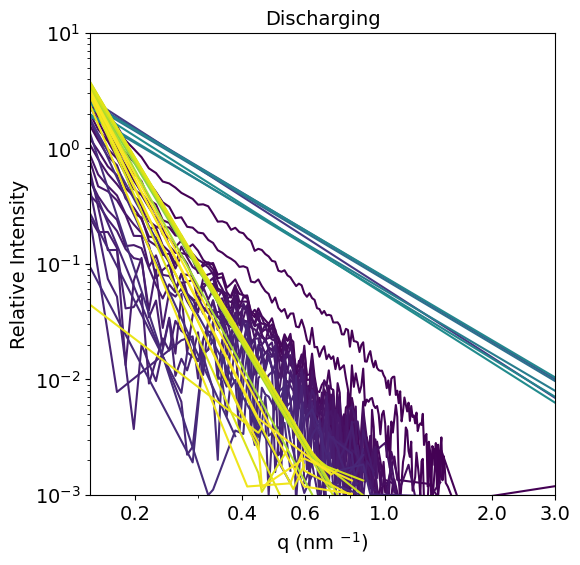

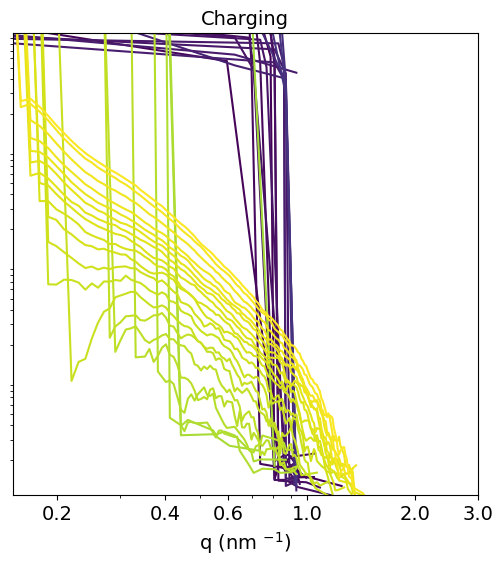

In [32]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.ndimage import uniform_filter1d

file_list = file_dictionary
# Set up the normalization for color mapping
norm_discharging = Normalize(vmin=starting_file, vmax=discharge_file - 20)
norm_charging = Normalize(vmin=discharge_file + 20, vmax=last_file)

# Define axis limits and labels
x_lim_min = 0.15
x_lim_max = 3
y_lim_min = 0.001
y_lim_max = 10
fntsize = 14

# --- Plot 1: Discharging ---
plt.figure(figsize=(6,6))
for file_number in range(starting_file, discharge_file - 20):
    X_data = 10 * file_list[file_number].iloc[:, 0]  # Convert from inverse Angstrom to inverse nanometer
    Y_data = file_list[file_number].iloc[:, 1] - file_list[discharge_file].iloc[:, 1]
    
    # Filter out points with Y_data <= 0.001
    mask = Y_data > 0.0008
    X_data = X_data[mask]
    Y_data = uniform_filter1d(Y_data[mask], size=1)
    #Y_data = Y_data[mask]
    # Plot with color based on file number
    color = cm.viridis(norm_discharging(file_number))
    plt.plot(X_data, Y_data, label=str(time_stamp[file_number]), color=color)

plt.xlim(x_lim_min, x_lim_max)
plt.ylim(y_lim_min, y_lim_max)
plt.tick_params(labelsize = fntsize)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (nm $^{-1}$)', fontsize=fntsize)
plt.ylabel('Relative Intensity', fontsize=fntsize)
plt.title('Discharging', fontsize=fntsize)

# Set custom x-ticks and labels
plt.xticks([0.2,0.4, 0.6, 1.0,2.0,3.0], ['0.2','0.4','0.6', '1.0','2.0','3.0'], fontsize= fntsize)

plt.savefig("discharging.png", dpi=600, format='png')


# --- Plot 2: Charging ---
plt.figure(figsize=(6,6))
for file_number in range(discharge_file + 20, last_file):
    X_data = 10 * file_list[file_number].iloc[:, 0]  # Convert from inverse Angstrom to inverse nanometer
    Y_data = file_list[file_number].iloc[:, 1] - file_list[discharge_file].iloc[:, 1]
    
    # Filter out points with Y_data <= 0.001
    mask = Y_data > 0.0008
    X_data = X_data[mask]
    Y_data = uniform_filter1d(Y_data[mask], size=5)
    #Y_data = Y_data[mask]
    # Plot with color based on file number
    color = cm.viridis(norm_charging(file_number))
    plt.plot(X_data, Y_data, label=str(time_stamp[file_number]), color=color)

plt.xlim(x_lim_min, x_lim_max)
plt.ylim(y_lim_min, y_lim_max)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (nm $^{-1}$)', fontsize=fntsize)
plt.title('Charging', fontsize=fntsize)

# Set custom x-ticks and labels
plt.xticks([0.2,0.4, 0.6, 1.0,2.0,3.0], ['0.2','0.4','0.6', '1.0','2.0','3.0'], fontsize = fntsize)

plt.yticks([])  # Remove y-axis ticks and labels


plt.savefig("charging.png", dpi=600, format='png')


# Manually plot certain saxs and waxs file

In [ ]:
# Manual data plotting SAXS

for ikey in range(1,10):
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    plt.plot(X_data, Y_data)
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

plt.xscale('log')
plt.yscale('log')

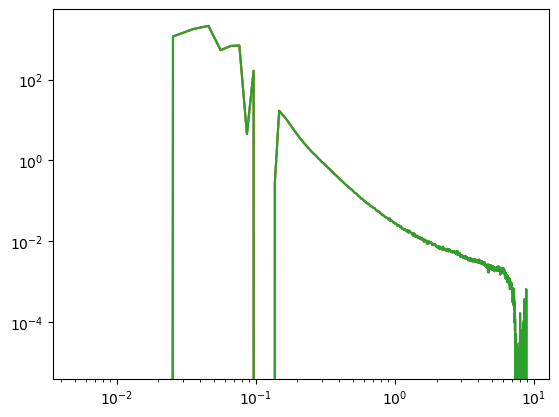

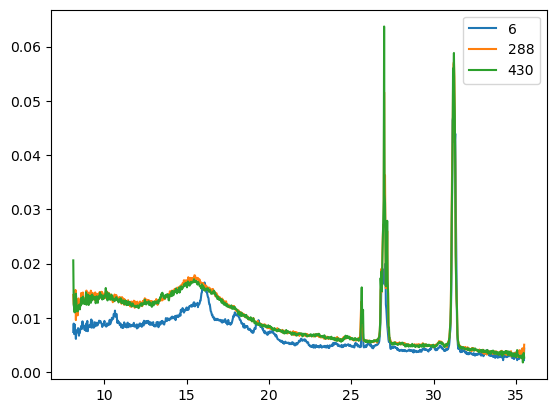

In [29]:
# Manual data plotting WAXS
plt.figure()
for ikey in range(347,350):
    X_data = 10*emptyCell_corrected_saxs_files[169].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = emptyCell_corrected_saxs_files[169].iloc[:,1]
    plt.plot(X_data, Y_data)
plt.xscale('log')
plt.yscale('log')
plt.figure()
for ikey in [6,288,430]:
    X_data = 10*file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    plt.plot(X_data, Y_data, label= ikey)
    
plt.legend()

# Find average intensity within a certain q range

In [ ]:

# Initialize the figure
plt.figure()

# Initialize data
fileset_dictionary = emptyCell_corrected_saxs_files
intensity_dictionary = {}
q_min_nm = 0.2
q_max_nm = 0.5

# Convert x-axis data for sample
x_sample_data = 10 * fileset_dictionary[1].iloc[:, 0]  # Converted from inverse Å to nm
key1 = np.where((x_sample_data <= q_max_nm) & (x_sample_data >= q_min_nm))[0]

# Iterate through each file and accumulate intensity within the range
for idx, file in enumerate(range(starting_file, last_file)):
    intensity_temp = 0
    for entry in key1:
        intensity_temp += fileset_dictionary[file].iloc[entry, 1]  # Assuming intensity is in column 1

    # Save intensity and plot it
    intensity_dictionary[file] = intensity_temp
      # Scatter plot with `idx` as x-axis position
x_values = list(intensity_dictionary.keys())      # File names or identifiers as x-axis labels
y_values = list(intensity_dictionary.values())
plt.plot(x_values, y_values, marker='o')
# Finalize the plot
plt.xlabel('Files')
plt.ylabel('Summed Intensity')
#plt.xticks(range(len(fileset_dictionary)), list(fileset_dictionary.keys()), rotation=90)  # Label x-axis with file names
plt.show()



# 3D Waterfall plot 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


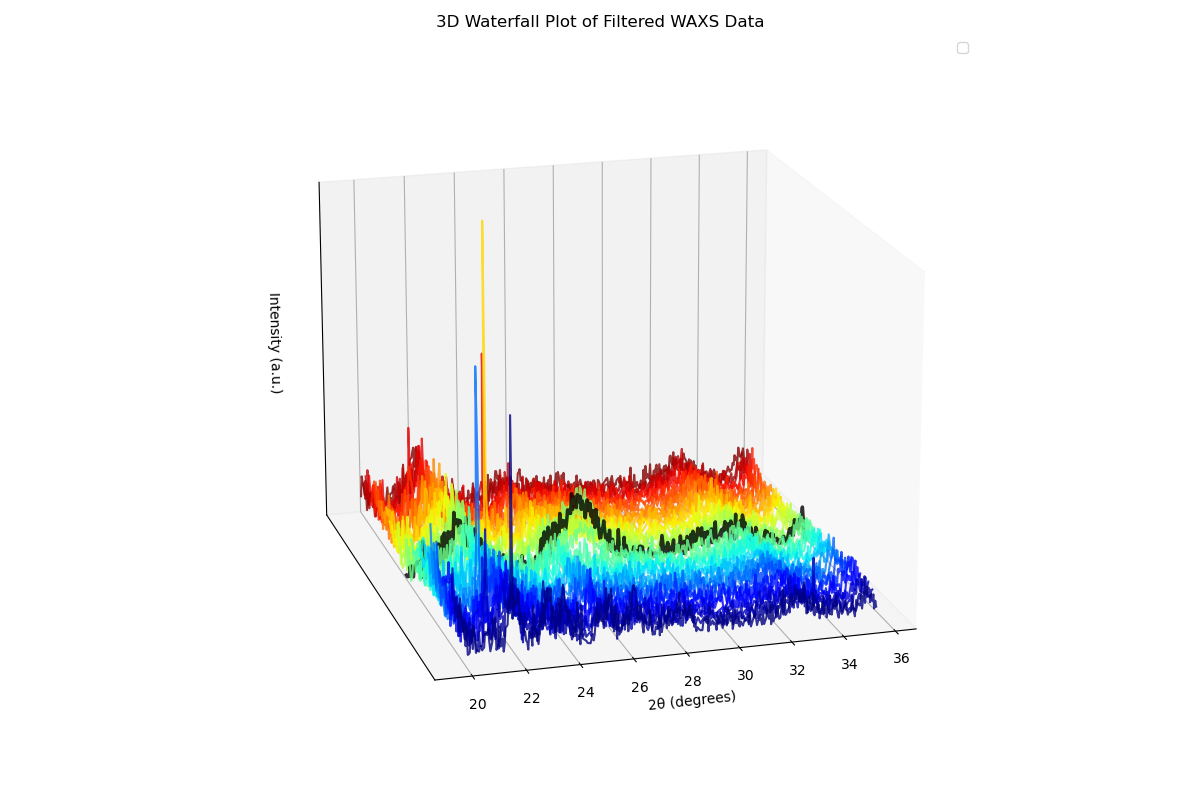

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

# Assuming data_to_plot, starting_file, last_file, saxs_file_numbers, and discharge_file are defined
data_to_plot = corrected_individual_waxs_files

# Wavelength for Cu Kα in nm
wavelength = 0.15406  # nm

# Function to convert q (nm^-1) to 2theta (degrees)
def q_to_two_theta(q_values, wavelength):
    return 2 * np.degrees(np.arcsin((q_values * wavelength) / (4 * np.pi)))

# Initialize the figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
plt.title("3D Waterfall Plot of Filtered WAXS Data")

# Define filtering limits
q_min, q_max = 14, 30
intensity_min, intensity_max = 0, 0.02  # Adjust as necessary

# Base offset for the waterfall plot
base_offset = 0.0
offset_increment = 0.000002  # Smaller value to improve spacing

# Set transparency
transparency = 0.8

# List of keys and reverse it
keys = list(range(starting_file, last_file + 1, 10))
keys.reverse()

# Ensure discharge_file is included in keys
if discharge_file not in keys:
    keys.append(discharge_file)
    keys = sorted(keys, reverse=True)  # Keep keys in reverse order for consistency

# Adjust the saxs_file_numbers list to exclude the first and last entries
adjusted_saxs_file_numbers = saxs_file_numbers[1:-1]

for ikey in keys:
    # Extract X and Y values
    original_q = 10 * data_to_plot[ikey].iloc[:, 0]  # q values in nm^-1
    original_Y = data_to_plot[ikey].iloc[:, 1]  # Intensity values
    
    # Convert q to 2theta
    converted_two_theta = q_to_two_theta(original_q, wavelength)
    
    # Filter data based on limits
    filtered_indices = (original_q >= q_min) & (original_q <= q_max) & (original_Y >= intensity_min) & (original_Y <= intensity_max)
    filtered_two_theta = converted_two_theta[filtered_indices]
    filtered_Y = original_Y[filtered_indices]
    
    # Apply vertical offset for Z-axis
    offset = base_offset + (ikey - starting_file) * offset_increment
    Z = np.full_like(filtered_two_theta, offset)
    
    # Check if the current file is the discharge file
    if ikey == discharge_file:
        # Plot the discharge file in black and bold
        ax.plot(filtered_two_theta, Z, filtered_Y, 
                color='black', linewidth=2.5, alpha=transparency)
    else:
        # Plot other files with default style
        ax.plot(filtered_two_theta, Z, filtered_Y, 
                color=cm.jet((ikey - starting_file) / (last_file - starting_file)), 
                alpha=transparency)

# Set axis labels
ax.set_xlabel('2θ (degrees)')  # Update x-axis label to 2theta
ax.set_yticks([])  # Hide y-ticks for offset
ax.set_zticks([])  # Hide z-ticks for intensity
ax.set_zlabel('Intensity (a.u.)')

# Add legend for discharge file
ax.legend(loc="upper right")

# Adjust view angle
ax.view_init(elev=18, azim=-106)

# Show plot
plt.tight_layout()
plt.show()
